<a href="https://colab.research.google.com/github/siyadalvi0331/CSL701-CE06_Machine-Learning-Lab/blob/main/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

siya dalvi
ce06

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


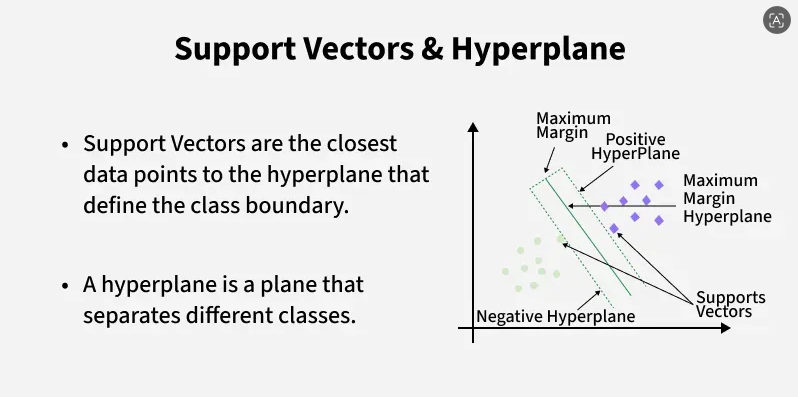
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
# Task 1: Import Libraries and Load Dataset

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Iris dataset
iris = datasets.load_iris()

# Store features and target
X = iris.data
y = iris.target

# Display dataset information
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Dataset shape:", X.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Dataset shape: (150, 4)


# Task 2: Explore the Dataset

In [2]:
# Task 2: Explore the Dataset

# Display first 5 samples
print("First 5 samples:")
print(X[:5])

# Display target values
print("\nFirst 5 target values:")
print(y[:5])

# Display dataset shape
print("\nDataset shape:")
print(X.shape)

# Display feature names
print("\nFeature names:")
print(iris.feature_names)

# Display target names
print("\nTarget names:")
print(iris.target_names)

# Check number of samples in each class
print("\nNumber of samples in each class:")
print(np.bincount(y))

# Check for missing values
print("\nMissing values:")
print(np.isnan(X).sum())


First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First 5 target values:
[0 0 0 0 0]

Dataset shape:
(150, 4)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Number of samples in each class:
[50 50 50]

Missing values:
0


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [3]:
# Task 3: Select Features and Target

# Iris dataset from sklearn does not contain an Id column.
# Select all 4 available features as input features
X = iris.data

# Select target variable
y = iris.target

# Display selected features and target
print("Selected Features:")
print(iris.feature_names)

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Classes:")
print(iris.target_names)

Selected Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Feature Shape: (150, 4)
Target Shape: (150,)

Target Classes:
['setosa' 'versicolor' 'virginica']


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [4]:
# Task 4: Split and Scale the Data

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Display the shapes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)
Training target shape: (120,)
Testing target shape: (30,)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [5]:
# Task 5: Implement Linear SVM

# Create Linear SVM model
linear_svm = SVC(kernel='linear', random_state=42)

# Train the model
linear_svm.fit(X_train, y_train)

# Make predictions on test data
y_pred_linear = linear_svm.predict(X_test)

# Display predictions
print("Predicted values:")
print(y_pred_linear)

print("\nActual values:")
print(y_test)

Predicted values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Actual values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [6]:
# Task 6: Evaluate Linear SVM

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_linear)

print("Accuracy of Linear SVM:", accuracy)

# Generate confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_linear)

print("\nConfusion Matrix:")
print(cm)

# Generate classification report
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_linear,
    target_names=iris.target_names
))

Accuracy of Linear SVM: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

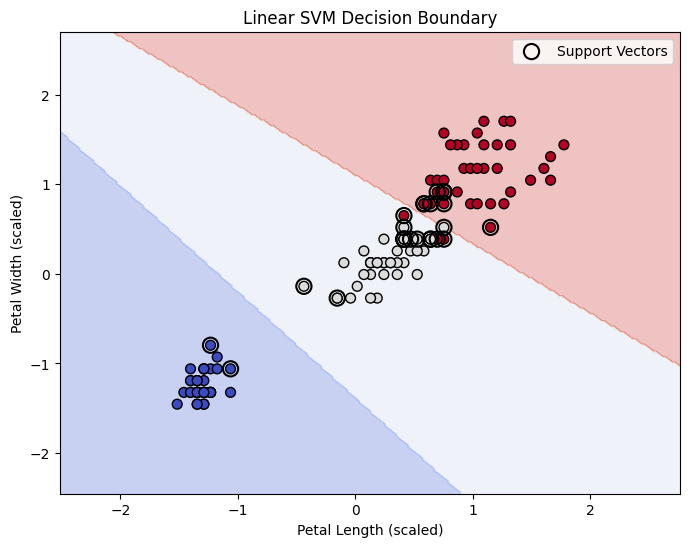

In [7]:
# Task 7: Visualize SVM Decision Boundary

# Select Petal Length and Petal Width
# Petal Length = column 2, Petal Width = column 3
X_2D = iris.data[:, [2, 3]]
y_2D = iris.target

# Split the 2-D dataset
X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D, y_2D,
    test_size=0.2,
    random_state=42,
    stratify=y_2D
)

# Scale the selected features
scaler_2D = StandardScaler()

X_train_2D = scaler_2D.fit_transform(X_train_2D)
X_test_2D = scaler_2D.transform(X_test_2D)

# Train Linear SVM
svm_2D = SVC(kernel='linear', random_state=42)
svm_2D.fit(X_train_2D, y_train_2D)

# Create a mesh grid for plotting
x_min = X_train_2D[:, 0].min() - 1
x_max = X_train_2D[:, 0].max() + 1
y_min = X_train_2D[:, 1].min() - 1
y_max = X_train_2D[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict the class for each point in the mesh
Z = svm_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))

plt.contourf(
    xx, yy, Z,
    alpha=0.3,
    cmap=plt.cm.coolwarm
)

# Plot training data points
scatter = plt.scatter(
    X_train_2D[:, 0],
    X_train_2D[:, 1],
    c=y_train_2D,
    cmap=plt.cm.coolwarm,
    edgecolors='k',
    s=50
)

# Highlight support vectors
plt.scatter(
    svm_2D.support_vectors_[:, 0],
    svm_2D.support_vectors_[:, 1],
    s=120,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='Support Vectors'
)

# Labels and title
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()

plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

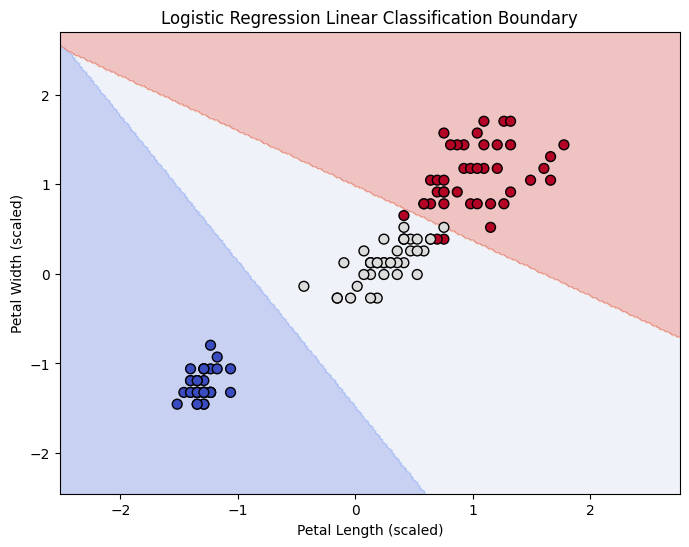

In [8]:
# Task 8: Normal Linear Classification Boundary

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=200,
    random_state=42
)

# Train the model using the same 2-D scaled training data
logistic_model.fit(X_train_2D, y_train_2D)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_2D)

# Create mesh grid for decision boundary
x_min = X_train_2D[:, 0].min() - 1
x_max = X_train_2D[:, 0].max() + 1
y_min = X_train_2D[:, 1].min() - 1
y_max = X_train_2D[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict classes for mesh points
Z = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))

plt.contourf(
    xx, yy, Z,
    alpha=0.3,
    cmap=plt.cm.coolwarm
)

# Plot training data points
plt.scatter(
    X_train_2D[:, 0],
    X_train_2D[:, 1],
    c=y_train_2D,
    cmap=plt.cm.coolwarm,
    edgecolors='k',
    s=50
)

# Labels and title
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Logistic Regression Linear Classification Boundary")

plt.show()


# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

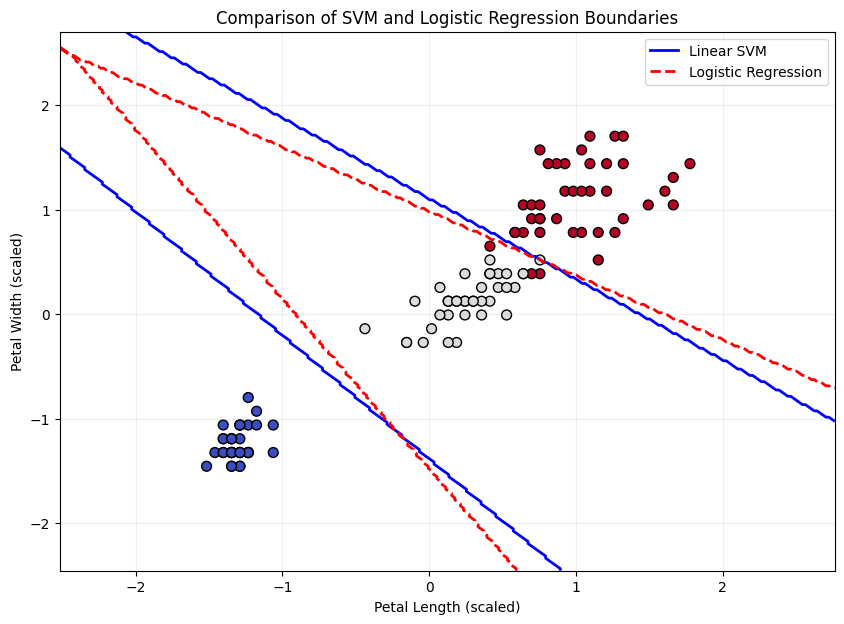

In [9]:
# Task 9: Compare SVM and Logistic Regression Boundaries

# Create mesh grid
x_min = X_train_2D[:, 0].min() - 1
x_max = X_train_2D[:, 0].max() + 1
y_min = X_train_2D[:, 1].min() - 1
y_max = X_train_2D[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predictions from Linear SVM
Z_svm = svm_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svm = Z_svm.reshape(xx.shape)

# Predictions from Logistic Regression
Z_logistic = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_logistic = Z_logistic.reshape(xx.shape)

# Create plot
plt.figure(figsize=(10, 7))

# Plot SVM decision boundary
plt.contour(
    xx, yy, Z_svm,
    levels=[0.5, 1.5],
    colors='blue',
    linewidths=2
)

# Plot Logistic Regression decision boundary
plt.contour(
    xx, yy, Z_logistic,
    levels=[0.5, 1.5],
    colors='red',
    linewidths=2,
    linestyles='--'
)

# Plot data points
plt.scatter(
    X_train_2D[:, 0],
    X_train_2D[:, 1],
    c=y_train_2D,
    cmap=plt.cm.coolwarm,
    edgecolors='k',
    s=50
)

# Create legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='blue', lw=2,
           label='Linear SVM'),
    Line2D([0], [0], color='red', lw=2,
           linestyle='--',
           label='Logistic Regression')
]

plt.legend(handles=legend_elements)

# Labels and title
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Comparison of SVM and Logistic Regression Boundaries")
plt.grid(alpha=0.2)

plt.show()



# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [10]:
# Task 10: Compare Performance of Linear SVM and Logistic Regression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Linear SVM Performance
# -----------------------------

# Make predictions using Linear SVM
y_pred_svm = svm_2D.predict(X_test_2D)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test_2D, y_pred_svm)

print("===== Linear SVM =====")
print("Accuracy:", svm_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_2D, y_pred_svm))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test_2D,
    y_pred_svm,
    target_names=iris.target_names
))


# -----------------------------
# Logistic Regression Performance
# -----------------------------

# Predictions using Logistic Regression
y_pred_lr = logistic_model.predict(X_test_2D)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test_2D, y_pred_lr)

print("\n===== Logistic Regression =====")
print("Accuracy:", lr_accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_2D, y_pred_lr))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test_2D,
    y_pred_lr,
    target_names=iris.target_names
))


# -----------------------------
# Final Accuracy Comparison
# -----------------------------

print("\n===== Accuracy Comparison =====")
print("Linear SVM Accuracy:", svm_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)

if svm_accuracy > lr_accuracy:
    print("Linear SVM performs better.")
elif lr_accuracy > svm_accuracy:
    print("Logistic Regression performs better.")
else:
    print("Both models have the same accuracy.")

===== Linear SVM =====
Accuracy: 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


===== Logistic Regression =====
Accuracy: 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.